# Анализ и визуализация результатов финального Fine-tuning (SSL-энкодер 10 эпохи!) на Benchmark-выборке: 4 стратегии и Scratch

### Импорты и базовые настройки

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [2]:
COLORS = {
    "scratch": "black",
    "partial_ft": "pink",
    "warmup": "purple",
    "full_ft": "blue",
    "low_lr_encoder": "red"
}

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

STRATEGY_ORDER = [
    "scratch",
    "full_ft",
    "low_lr_encoder",
    "partial_ft",
    "warmup",
]

### Пути

In [3]:
# === INPUT PATHS ===

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parents[2]  

OUTPUTS_DIR = PROJECT_ROOT / "outputs"  / "downstream"

FT_CSV = OUTPUTS_DIR / "test_10epochs" / "tables" / 'FT_strategies_summary.csv'
SCRATCH_CSV = OUTPUTS_DIR / "test" / "tables" /'Scratch_summary.csv'

# === OUTPUT DIRS ===
OUT_DIR =  OUTPUTS_DIR / "test_10epochs"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FT_CSV exists:", FT_CSV.exists(), FT_CSV)
print("SCRATCH_CSV exists:", SCRATCH_CSV.exists(), SCRATCH_CSV)
print("Output dir:", OUT_DIR.resolve())

FT_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\tables\FT_strategies_summary.csv
SCRATCH_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\tables\Scratch_summary.csv
Output dir: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs


### Загрузка файлов

In [10]:
df_ft = pd.read_csv(FT_CSV)
df_scratch = pd.read_csv(SCRATCH_CSV)

print("df_ft shape:", df_ft.shape)
print("df_scratch shape:", df_scratch.shape)

display(df_ft.head())
display(df_scratch.head())

df_ft shape: (1464, 33)
df_scratch shape: (366, 33)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-chec...,0.00003,0.0003,0.001,NaN,0.500,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.529586,0.346067,0.211382,0.123158,0.745223,0.007806,benchmark__subj_051__p0__ssl_ft__seed42__full_...,NaN,/kaggle/working/stage5_results/stage5_final_ev...,ok,NaN
1,subj_051,benchmark,0,ssl_ft,low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-chec...,0.00003,0.0003,0.001,NaN,0.500,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.529586,0.346067,0.211382,0.123158,0.745223,0.007806,benchmark__subj_051__p0__ssl_ft__seed42__low_l...,NaN,/kaggle/working/stage5_results/stage5_final_ev...,ok,NaN
2,subj_051,benchmark,0,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-chec...,0.00003,0.0003,0.001,NaN,0.500,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.529586,0.346067,0.211382,0.123158,0.745223,0.007806,benchmark__subj_051__p0__ssl_ft__seed42__parti...,NaN,/kaggle/working/stage5_results/stage5_final_ev...,ok,NaN
3,subj_051,benchmark,0,ssl_ft,warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-chec...,0.00003,0.0003,0.001,3.0,0.500,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.529586,0.346067,0.211382,0.123158,0.745223,0.007806,benchmark__subj_051__p0__ssl_ft__seed42__warmu...,NaN,/kaggle/working/stage5_results/stage5_final_ev...,ok,NaN
4,subj_051,benchmark,10,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-chec...,0.00003,0.0003,0.001,NaN,0.365,0.254545,623,125,2670,74,15,314,1.0,0.72881,11.0,0.496729,0.375281,0.204198,0.120090,0.681529,0.000777,benchmark__subj_051__p10__ssl_ft__seed42__full...,/kaggle/working/stage5_results/stage5_final_ev...,/kaggle/working/stage5_results/stage5_final_ev...,ok,NaN


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,0,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.499638,0.882397,0.000000,0.000000,0.000000,0.006737,benchmark__subj_051__p0__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
1,subj_051,benchmark,10,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.254545,623,125,2670,74,15,314,6.0,0.674627,16.0,0.550267,0.330337,0.217163,0.125888,0.789809,0.021560,benchmark__subj_051__p10__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
2,subj_051,benchmark,20,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.39,0.240964,1246,250,2670,148,30,314,3.0,0.686443,13.0,0.547048,0.245693,0.213281,0.121549,0.869427,0.018001,benchmark__subj_051__p20__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
3,subj_051,benchmark,40,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.233010,2492,499,2670,296,59,314,2.0,0.693760,12.0,0.563142,0.351685,0.213539,0.124536,0.748408,0.032400,benchmark__subj_051__p40__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
4,subj_051,benchmark,60,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.05,0.212664,3738,748,2670,444,89,314,1.0,0.704080,11.0,0.551749,0.117603,0.210456,0.117603,1.000000,0.008633,benchmark__subj_051__p60__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


In [11]:
print("FT columns:")
print(df_ft.columns.tolist())

print("\nScratch columns:")
print(df_scratch.columns.tolist())

FT columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']

Scratch columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


### Приведение с единому формату и Объединение таблиц (только нужные признаки)

In [12]:
# --- копии ---
df_ft = df_ft.copy()
df_scratch = df_scratch.copy()

# --- создаём strategy ---
df_ft["strategy"] = df_ft["ft_strategy"].astype(str)
df_scratch["strategy"] = "scratch"

# --- приводим p ---
df_ft["p"] = df_ft["p"].astype(int)
df_scratch["p"] = df_scratch["p"].astype(int)

# --- оставляем только нужные колонки ---
core_cols = [
    "subject_id",
    "p",
    "strategy",
    "auc",
    "f1",
    "accuracy",
    "precision",
    "recall",
    "fdr"
]

optional_cols = ["group"]  # можно убрать, если не нужен

keep_cols = core_cols + optional_cols

df_ft = df_ft[keep_cols]
df_scratch = df_scratch[keep_cols]

# --- объединяем ---
df_all = pd.concat([df_ft, df_scratch], ignore_index=True)

print("df_all shape:", df_all.shape)
display(df_all.head())

df_all shape: (1830, 10)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group
0,subj_051,0,full_ft,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark
1,subj_051,0,low_lr_encoder,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark
2,subj_051,0,partial_ft,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark
3,subj_051,0,warmup,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark
4,subj_051,10,full_ft,0.496729,0.204198,0.375281,0.120090,0.681529,0.000777,benchmark


#### Проверка базовых значений

In [14]:
print("Unique strategies:", sorted(df_all["strategy"].dropna().unique().tolist()))
print("Unique p:", sorted(df_all["p"].dropna().unique().tolist()))
print("Number of subjects:", df_all["subject_id"].nunique())

Unique strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'scratch', 'warmup']
Unique p: [0, 10, 20, 40, 60, 100]
Number of subjects: 61


#### Проверка ключевых метрик и обязательных колонок

In [15]:
required_cols = [
    "subject_id", "p", "strategy",
    "auc", "f1", "accuracy", "precision", "recall", "fdr"
]

missing_required = [c for c in required_cols if c not in df_all.columns]
print("Missing required columns:", missing_required)

Missing required columns: []


#### Проверка дубликатов по ключу subject_id × p × strategy

In [16]:
key_cols = ["subject_id", "p", "strategy"]

dup_mask = df_all.duplicated(subset=key_cols, keep=False)
df_dups = df_all.loc[dup_mask].sort_values(key_cols)

print("Number of duplicated rows by key:", len(df_dups))
display(df_dups.head(20))

Number of duplicated rows by key: 0


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group


#### Проверка пропусков в метриках

In [17]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

na_report = df_all[metric_cols].isna().sum().sort_values(ascending=False)
print("NaN counts in metrics:")
display(na_report.to_frame("n_missing"))

NaN counts in metrics:


,n_missing
auc,0
f1,0
accuracy,0
precision,0
recall,0
fdr,0


In [18]:
# Проверка пропусков по стратегиям
na_by_strategy = df_all.groupby("strategy")[metric_cols].apply(lambda x: x.isna().sum())
display(na_by_strategy)

,auc,f1,accuracy,precision,recall,fdr
strategy,,,,,,
full_ft,0,0,0,0,0,0
low_lr_encoder,0,0,0,0,0,0
partial_ft,0,0,0,0,0,0
scratch,0,0,0,0,0,0
warmup,0,0,0,0,0,0


#### Проверка числа наблюдений по стратегиям и по p

In [19]:
count_by_strategy_p = (
    df_all.groupby(["strategy", "p"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(count_by_strategy_p)

p,0,10,20,40,60,100
strategy,,,,,,
full_ft,61,61,61,61,61,61
low_lr_encoder,61,61,61,61,61,61
partial_ft,61,61,61,61,61,61
scratch,61,61,61,61,61,61
warmup,61,61,61,61,61,61


#### Проверка парности по субъектам

In [20]:
subjects_by_strategy_p = (
    df_all.groupby(["strategy", "p"])["subject_id"]
    .apply(lambda s: set(s.tolist()))
)

all_strategies = sorted(df_all["strategy"].unique())
all_p = sorted(df_all["p"].unique())

pairing_report = []

for p in all_p:
    base_subjects = subjects_by_strategy_p.get(("scratch", p), set())
    for strategy in all_strategies:
        cur_subjects = subjects_by_strategy_p.get((strategy, p), set())
        pairing_report.append({
            "p": p,
            "strategy": strategy,
            "n_subjects": len(cur_subjects),
            "same_as_scratch": cur_subjects == base_subjects,
            "missing_vs_scratch": len(base_subjects - cur_subjects),
            "extra_vs_scratch": len(cur_subjects - base_subjects),
        })

pairing_report_df = pd.DataFrame(pairing_report).sort_values(["p", "strategy"])
display(pairing_report_df)

,p,strategy,n_subjects,same_as_scratch,missing_vs_scratch,extra_vs_scratch
0,0,full_ft,61,True,0,0
1,0,low_lr_encoder,61,True,0,0
2,0,partial_ft,61,True,0,0
3,0,scratch,61,True,0,0
4,0,warmup,61,True,0,0
5,10,full_ft,61,True,0,0
6,10,low_lr_encoder,61,True,0,0
7,10,partial_ft,61,True,0,0
8,10,scratch,61,True,0,0
9,10,warmup,61,True,0,0


### Сохраняем промежуточную объединённую таблицу

In [ ]:
# df_all.to_csv(TAB_DIR / "combined_all_results.csv", index=False)
# pairing_report_df.to_csv(TAB_DIR / "pairing_report.csv", index=False)
# count_by_strategy_p.to_csv(TAB_DIR / "count_by_strategy_p.csv")

### Короткий автоматический sanity-check

In [22]:
expected_strategies = {"scratch", "full_ft", "low_lr_encoder", "partial_ft", "warmup"}
expected_p = {0, 10, 20, 40, 60, 100}

actual_strategies = set(df_all["strategy"].dropna().unique())
actual_p = set(df_all["p"].dropna().unique())

print("Strategies OK:", actual_strategies == expected_strategies)
print("p values OK:", actual_p == expected_p)
print("No duplicate keys:", len(df_dups) == 0)
print("No missing metrics:", df_all[metric_cols].isna().sum().sum() == 0)

Strategies OK: True
p values OK: True
No duplicate keys: True
No missing metrics: True


## Формирование финальной аналитической таблицы

#### Базовая агрегация

In [23]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

summary = (
    df_all
    .groupby(["strategy", "p"])[metric_cols]
    .agg(["mean", "std", "median"])
)

# flatten columns
summary.columns = ["_".join(col) for col in summary.columns]

# добавим число субъектов
n_subjects = (
    df_all
    .groupby(["strategy", "p"])["subject_id"]
    .nunique()
    .rename("n_subjects")
)

summary = summary.join(n_subjects)

summary = summary.reset_index()

display(summary.head())

,strategy,p,auc_mean,auc_std,auc_median,f1_mean,f1_std,f1_median,accuracy_mean,accuracy_std,accuracy_median,precision_mean,precision_std,precision_median,recall_mean,recall_std,recall_median,fdr_mean,fdr_std,fdr_median,n_subjects
0,full_ft,0,0.500468,0.039525,0.502154,0.213283,0.077757,0.187868,0.316720,0.188047,0.268555,0.130210,0.052731,0.116883,0.754098,0.247213,0.850863,0.014134,0.068513,0.001788,61
1,full_ft,10,0.515429,0.058856,0.506589,0.227320,0.086788,0.200314,0.214511,0.170552,0.120605,0.134744,0.059883,0.116442,0.905382,0.188353,1.000000,0.031503,0.183493,0.001271,61
2,full_ft,20,0.523977,0.067795,0.510720,0.227002,0.078661,0.209934,0.199210,0.165208,0.117903,0.135100,0.058078,0.117517,0.922445,0.165372,1.000000,0.044686,0.224987,0.002815,61
3,full_ft,40,0.544566,0.088834,0.521576,0.238749,0.109943,0.210526,0.263111,0.205791,0.216840,0.148848,0.094805,0.117647,0.876496,0.192735,0.961957,0.103904,0.471102,0.004486,61
4,full_ft,60,0.560507,0.094888,0.538929,0.248787,0.115413,0.210936,0.297068,0.200934,0.255046,0.155443,0.104440,0.118089,0.857925,0.162671,0.898693,0.161479,0.704603,0.004771,61


#### Отдельная таблица mean ± std

In [24]:
def mean_std_str(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

table_mean_std = summary.copy()

for m in ["auc", "f1", "accuracy"]:
    table_mean_std[f"{m}_mean_std"] = table_mean_std.apply(
        lambda row: mean_std_str(row[f"{m}_mean"], row[f"{m}_std"]),
        axis=1
    )

cols_for_table = [
    "strategy", "p", "n_subjects",
    "auc_mean_std",
    "f1_mean_std",
    "accuracy_mean_std"
]

table_mean_std = table_mean_std[cols_for_table]

display(table_mean_std)

,strategy,p,n_subjects,auc_mean_std,f1_mean_std,accuracy_mean_std
0,full_ft,0,61,0.5005 ± 0.0395,0.2133 ± 0.0778,0.3167 ± 0.1880
1,full_ft,10,61,0.5154 ± 0.0589,0.2273 ± 0.0868,0.2145 ± 0.1706
2,full_ft,20,61,0.5240 ± 0.0678,0.2270 ± 0.0787,0.1992 ± 0.1652
3,full_ft,40,61,0.5446 ± 0.0888,0.2387 ± 0.1099,0.2631 ± 0.2058
4,full_ft,60,61,0.5605 ± 0.0949,0.2488 ± 0.1154,0.2971 ± 0.2009
5,full_ft,100,61,0.6465 ± 0.1310,0.3006 ± 0.1187,0.4653 ± 0.2478
6,low_lr_encoder,0,61,0.5005 ± 0.0395,0.2133 ± 0.0778,0.3167 ± 0.1880
7,low_lr_encoder,10,61,0.5168 ± 0.0584,0.2256 ± 0.0776,0.2347 ± 0.1582
8,low_lr_encoder,20,61,0.5217 ± 0.0609,0.2299 ± 0.0809,0.2073 ± 0.1254
9,low_lr_encoder,40,61,0.5325 ± 0.0653,0.2313 ± 0.0816,0.2059 ± 0.1269


#### Pivot-таблица

In [25]:
pivot_auc = table_mean_std.pivot(index="p", columns="strategy", values="auc_mean_std")
pivot_f1 = table_mean_std.pivot(index="p", columns="strategy", values="f1_mean_std")
pivot_acc = table_mean_std.pivot(index="p", columns="strategy", values="accuracy_mean_std")

print("AUC:")
display(pivot_auc)

print("\nF1:")
display(pivot_f1)

print("\nAccuracy:")
display(pivot_acc)

AUC:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.5005 ± 0.0395,0.5005 ± 0.0395,0.5005 ± 0.0395,0.5027 ± 0.0216,0.5005 ± 0.0395
10,0.5154 ± 0.0589,0.5168 ± 0.0584,0.5234 ± 0.0538,0.5145 ± 0.0555,0.5219 ± 0.0576
20,0.5240 ± 0.0678,0.5217 ± 0.0609,0.5307 ± 0.0648,0.5232 ± 0.0564,0.5273 ± 0.0632
40,0.5446 ± 0.0888,0.5325 ± 0.0653,0.5465 ± 0.0727,0.5357 ± 0.0589,0.5386 ± 0.0674
60,0.5605 ± 0.0949,0.5424 ± 0.0703,0.5563 ± 0.0821,0.5416 ± 0.0586,0.5460 ± 0.0718
100,0.6465 ± 0.1310,0.5596 ± 0.0844,0.5744 ± 0.0841,0.5560 ± 0.0695,0.5628 ± 0.0847



F1:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.2133 ± 0.0778,0.2133 ± 0.0778,0.2133 ± 0.0778,0.0000 ± 0.0000,0.2133 ± 0.0778
10,0.2273 ± 0.0868,0.2256 ± 0.0776,0.2274 ± 0.0812,0.2302 ± 0.0821,0.2277 ± 0.0817
20,0.2270 ± 0.0787,0.2299 ± 0.0809,0.2321 ± 0.0797,0.2287 ± 0.0803,0.2300 ± 0.0809
40,0.2387 ± 0.1099,0.2313 ± 0.0816,0.2368 ± 0.0807,0.2312 ± 0.0831,0.2324 ± 0.0838
60,0.2488 ± 0.1154,0.2338 ± 0.0855,0.2416 ± 0.0888,0.2313 ± 0.0829,0.2339 ± 0.0845
100,0.3006 ± 0.1187,0.2432 ± 0.1026,0.2457 ± 0.0883,0.2353 ± 0.0855,0.2444 ± 0.0992



Accuracy:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.3167 ± 0.1880,0.3167 ± 0.1880,0.3167 ± 0.1880,0.8703 ± 0.0528,0.3167 ± 0.1880
10,0.2145 ± 0.1706,0.2347 ± 0.1582,0.1970 ± 0.1338,0.1828 ± 0.1329,0.2152 ± 0.1455
20,0.1992 ± 0.1652,0.2073 ± 0.1254,0.2111 ± 0.1329,0.2035 ± 0.1464,0.2081 ± 0.1217
40,0.2631 ± 0.2058,0.2059 ± 0.1269,0.2427 ± 0.1533,0.2185 ± 0.1344,0.2048 ± 0.1272
60,0.2971 ± 0.2009,0.2271 ± 0.1466,0.2626 ± 0.1708,0.2015 ± 0.1275,0.2157 ± 0.1404
100,0.4653 ± 0.2478,0.2215 ± 0.1745,0.2854 ± 0.1801,0.2099 ± 0.1430,0.2498 ± 0.1755


#### Сохраняем таблицы

In [ ]:
# summary.to_csv(TAB_DIR / "summary_full_stats.csv", index=False)
# table_mean_std.to_csv(TAB_DIR / "summary_mean_std.csv", index=False)

# pivot_auc.to_csv(TAB_DIR / "pivot_auc.csv")
# pivot_f1.to_csv(TAB_DIR / "pivot_f1.csv")
# pivot_acc.to_csv(TAB_DIR / "pivot_accuracy.csv")

## Основные графики

- ROC-AUC vs p
- F1 vs p
- Accuracy vs p

#### Подготовка данных для графиков

In [27]:
plot_df = (
    df_all
    .groupby(["strategy", "p"])[["auc", "f1", "accuracy"]]
    .agg(["mean", "std"])
)

plot_df.columns = ["_".join(col) for col in plot_df.columns]
plot_df = plot_df.reset_index()

display(plot_df.head())

,strategy,p,auc_mean,auc_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,full_ft,0,0.500468,0.039525,0.213283,0.077757,0.316720,0.188047
1,full_ft,10,0.515429,0.058856,0.227320,0.086788,0.214511,0.170552
2,full_ft,20,0.523977,0.067795,0.227002,0.078661,0.199210,0.165208
3,full_ft,40,0.544566,0.088834,0.238749,0.109943,0.263111,0.205791
4,full_ft,60,0.560507,0.094888,0.248787,0.115413,0.297068,0.200934


#### Функция для построения графика

In [28]:
def make_strategy_label(row):
    scenario = row.get("scenario", None)
    ft_strategy = row.get("ft_strategy", None)

    if scenario == "scratch":
        return "С нуля"
    if pd.notna(ft_strategy):
        return STRATEGY_RU.get(ft_strategy, str(ft_strategy))
    return str(scenario)

In [29]:
def draw_metric_plot(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in plot_df["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = plot_df[plot_df["strategy"] == strategy].copy()
        sub = sub.set_index("p").loc[p_values].reset_index()

        x = sub["p"]
        y = sub[f"{metric}_mean"]
        yerr = sub[f"{metric}_std"]

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")
    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

#### Строим графики

In [30]:
def plot_metric(metric, ylabel):
    draw_metric_plot(metric, ylabel)
    plt.show()

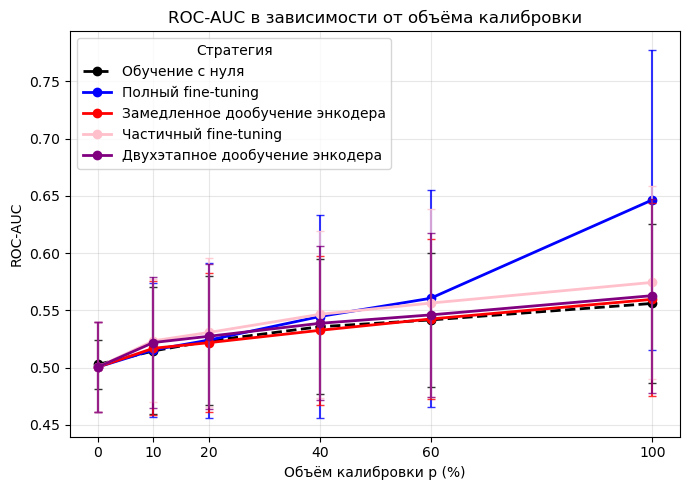

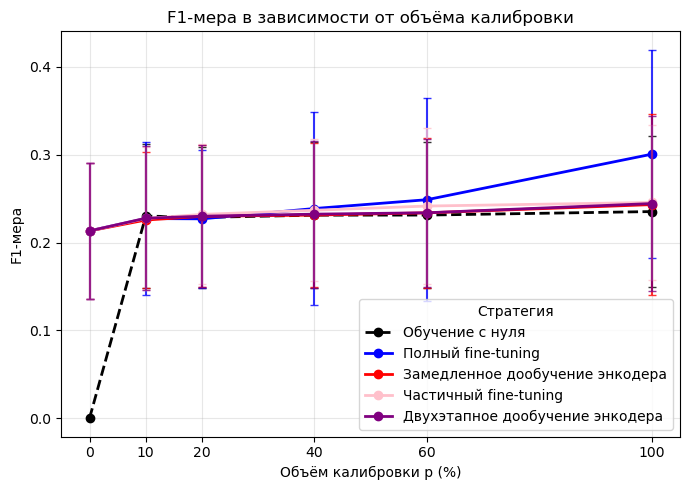

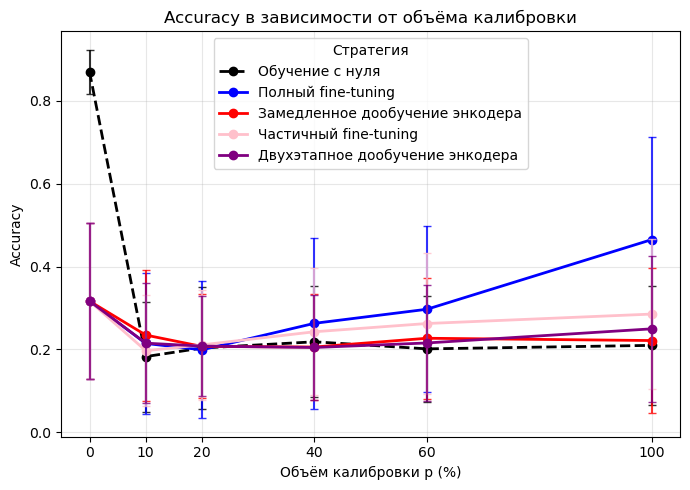

In [31]:
plot_metric("auc", "ROC-AUC")
plot_metric("f1", "F1-мера")
plot_metric("accuracy", "Accuracy")

#### Сохраняем графики

In [50]:
def save_plot(plot_func, metric, ylabel, filename):
    fig = plot_func(metric, ylabel)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [ ]:
save_plot(draw_metric_plot, "auc", "ROC-AUC", "auc_vs_p.png")
save_plot(draw_metric_plot, "f1", "F1-мера", "f1_vs_p.png")
save_plot(draw_metric_plot, "accuracy", "Accuracy", "accuracy_vs_p.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\auc_vs_p.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\f1_vs_p.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\accuracy_vs_p.png


## Графики выигрыша относительно scratch

#### per-subject delta

In [4]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")

In [6]:
metric_cols = ["auc", "f1", "accuracy"]

# scratch как база
df_scratch_base = (
    df_all[df_all["strategy"] == "scratch"]
    [["subject_id", "p"] + metric_cols]
    .rename(columns={m: f"{m}_scratch" for m in metric_cols})
    .copy()
)

# все не-scratch стратегии
df_non_scratch = df_all[df_all["strategy"] != "scratch"].copy()

# merge по subject_id и p
df_delta = df_non_scratch.merge(
    df_scratch_base,
    on=["subject_id", "p"],
    how="inner"
)

# считаем дельты
for m in metric_cols:
    df_delta[f"delta_{m}"] = df_delta[m] - df_delta[f"{m}_scratch"]

print("df_delta shape:", df_delta.shape)
display(df_delta.head())

df_delta shape: (1464, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch,f1_scratch,accuracy_scratch,delta_auc,delta_f1,delta_accuracy
0,subj_051,0,full_ft,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark,0.499638,0.000000,0.882397,0.029948,0.211382,-0.536330
1,subj_051,0,low_lr_encoder,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark,0.499638,0.000000,0.882397,0.029948,0.211382,-0.536330
2,subj_051,0,partial_ft,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark,0.499638,0.000000,0.882397,0.029948,0.211382,-0.536330
3,subj_051,0,warmup,0.529586,0.211382,0.346067,0.123158,0.745223,0.007806,benchmark,0.499638,0.000000,0.882397,0.029948,0.211382,-0.536330
4,subj_051,10,full_ft,0.496729,0.204198,0.375281,0.120090,0.681529,0.000777,benchmark,0.550267,0.217163,0.330337,-0.053539,-0.012964,0.044944


In [7]:
check_delta = (
    df_delta.groupby(["strategy", "p"])[["delta_auc", "delta_f1", "delta_accuracy"]]
    .agg(["mean", "std", "median"])
)

check_delta.columns = ["_".join(col) for col in check_delta.columns]
check_delta = check_delta.reset_index()

display(check_delta)

,strategy,p,delta_auc_mean,delta_auc_std,delta_auc_median,delta_f1_mean,delta_f1_std,delta_f1_median,delta_accuracy_mean,delta_accuracy_std,delta_accuracy_median
0,full_ft,0,-0.002255,0.046113,0.006171,0.213283,0.077757,0.187868,-0.553594,0.197227,-0.596078
1,full_ft,10,0.000947,0.040145,-0.000335,-0.002878,0.014719,0.000000,0.031698,0.182044,0.000000
2,full_ft,20,0.000740,0.039618,0.005590,-0.001649,0.020536,0.000000,-0.004257,0.125138,0.000000
3,full_ft,40,0.008906,0.056736,0.008443,0.007575,0.066030,0.000419,0.044597,0.191757,0.000000
4,full_ft,60,0.018933,0.052212,0.007993,0.017497,0.077074,0.000220,0.095616,0.188820,0.025339
5,full_ft,100,0.090449,0.106347,0.069728,0.065349,0.082608,0.021355,0.255408,0.244994,0.226280
6,low_lr_encoder,0,-0.002255,0.046113,0.006171,0.213283,0.077757,0.187868,-0.553594,0.197227,-0.596078
7,low_lr_encoder,10,0.002351,0.034375,-0.001928,-0.004568,0.017297,0.000000,0.051917,0.159408,0.004016
8,low_lr_encoder,20,-0.001498,0.031113,-0.002572,0.001228,0.011808,0.000000,0.003812,0.119481,0.000000
9,low_lr_encoder,40,-0.003141,0.034565,0.005840,0.000137,0.010283,0.000128,-0.012612,0.113171,-0.009265


#### Функция для delta-графика

In [51]:
def plot_delta_metric(delta_metric, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in df_delta["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} относительно Scratch")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

#### Строим Δ-графики

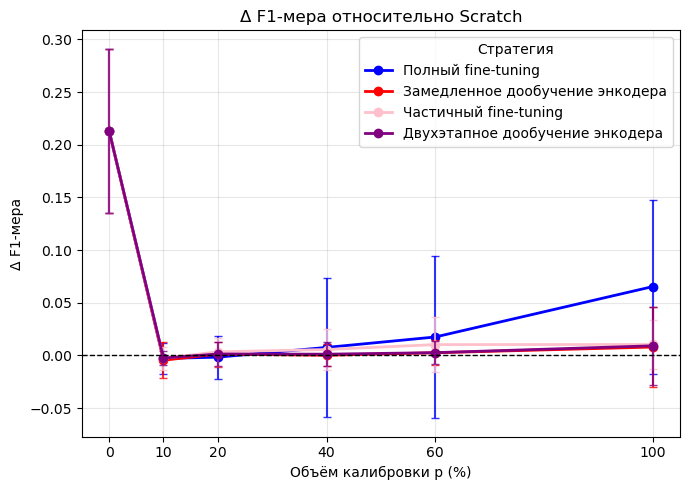

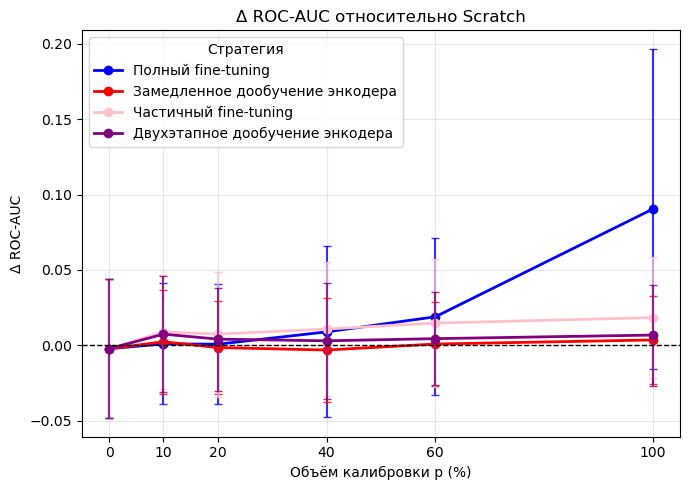

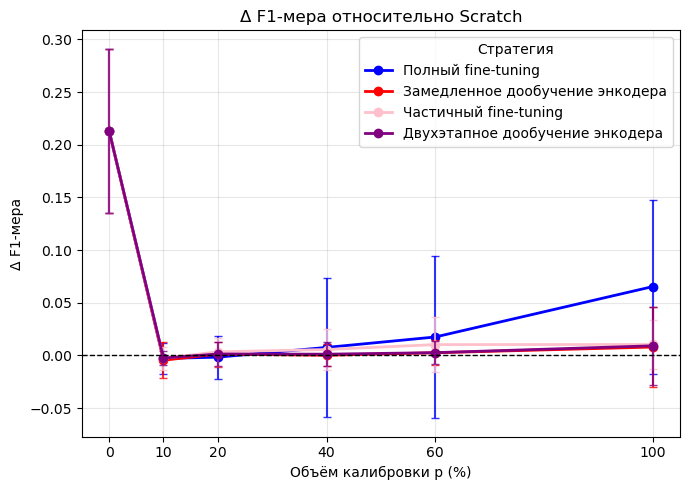

In [52]:
plot_delta_metric("delta_auc",  "Δ ROC-AUC")
plot_delta_metric("delta_f1", "Δ F1-мера")

#### Сохраняем Δ-графики

In [53]:
save_plot(plot_delta_metric, "delta_auc", "Δ ROC-AUC", "delta_auc_vs_p.png")
save_plot(plot_delta_metric, "delta_f1", "Δ F1-мера", "delta_f1_vs_scratch.png")
save_plot(plot_delta_metric, "delta_accuracy", "Δ Accuracy", "delta_accuracy_vs_scratch.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_auc_vs_p.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_f1_vs_scratch.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_accuracy_vs_scratch.png


## Парные статистические тесты

In [8]:
# Импорт статистики
from scipy.stats import wilcoxon

#### Функция для одного теста

In [9]:
def run_wilcoxon(df, metric, alternative="two-sided"):
    values = df[metric].dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

### Значимо ли Δ-метрика (относительно scratch) отличается от 0?

(двусторонний тест)

In [10]:
results = []

strategies = sorted(df_delta["strategy"].unique())
p_values = sorted(df_delta["p"].unique())

metrics = ["delta_auc", "delta_f1", "delta_accuracy"]

for p in p_values:
    for strategy in strategies:
        sub = df_delta[
            (df_delta["p"] == p) &
            (df_delta["strategy"] == strategy)
        ]

        for metric in metrics:
            p_val = run_wilcoxon(sub, metric)

            results.append({
                "p": p,
                "strategy": strategy,
                "metric": metric,
                "n": len(sub),
                "mean": sub[metric].mean(),
                "median": sub[metric].median(),
                "p_value": p_val
            })

stats_df = pd.DataFrame(results)
display(stats_df.head())

,p,strategy,metric,n,mean,median,p_value
0,0,full_ft,delta_auc,61,-0.002255,0.006171,3.673553e-01
1,0,full_ft,delta_f1,61,0.213283,0.187868,1.111165e-11
2,0,full_ft,delta_accuracy,61,-0.553594,-0.596078,1.111165e-11
3,0,low_lr_encoder,delta_auc,61,-0.002255,0.006171,3.673553e-01
4,0,low_lr_encoder,delta_f1,61,0.213283,0.187868,1.111165e-11


#### Поправка на множественные сравнения

In [ ]:
from statsmodels.stats.multitest import multipletests

stats_df["p_adj"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
stats_df["significant"] = stats_df["p_adj"] < 0.05

# display(stats_df)

#### Сохраняем таблицу стат анализа

In [12]:
stats_df.to_excel(TAB_DIR / "DELTAvsSCRATCH_STAT_ANALYSIS.xlsx", index=False)

#### Только значимые строки

In [58]:
significant_df = stats_df[stats_df["significant"] == True]

display(significant_df)

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
1,0,full_ft,delta_f1,61,0.213283,0.187868,1.111165e-11,1.000048e-10,True
2,0,full_ft,delta_accuracy,61,-0.553594,-0.596078,1.111165e-11,1.000048e-10,True
4,0,low_lr_encoder,delta_f1,61,0.213283,0.187868,1.111165e-11,1.000048e-10,True
5,0,low_lr_encoder,delta_accuracy,61,-0.553594,-0.596078,1.111165e-11,1.000048e-10,True
7,0,partial_ft,delta_f1,61,0.213283,0.187868,1.111165e-11,1.000048e-10,True
8,0,partial_ft,delta_accuracy,61,-0.553594,-0.596078,1.111165e-11,1.000048e-10,True
10,0,warmup,delta_f1,61,0.213283,0.187868,1.111165e-11,1.000048e-10,True
11,0,warmup,delta_accuracy,61,-0.553594,-0.596078,1.111165e-11,1.000048e-10,True
17,10,low_lr_encoder,delta_accuracy,61,0.051917,0.004016,7.855496e-03,3.142199e-02,True
22,10,warmup,delta_f1,61,-0.002481,0.000000,1.331000e-02,4.355999e-02,True


#### Только по AUC

In [ ]:
sig_auc_positive = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] > 0)
]

display(sig_auc_positive.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
48,60,full_ft,delta_auc,61,0.018933,0.007993,1.281636e-02,4.355999e-02,True
54,60,partial_ft,delta_auc,61,0.014745,0.007159,1.023337e-02,3.877909e-02,True
60,100,full_ft,delta_auc,61,0.090449,0.069728,1.271329e-07,8.321428e-07,True
66,100,partial_ft,delta_auc,61,0.018388,0.010802,1.243727e-03,5.969889e-03,True


In [60]:
for strategy in sorted(sig_auc_positive["strategy"].unique()):
    p_list = sig_auc_positive[sig_auc_positive["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant improvement at p = {p_list}")

full_ft: significant improvement at p = [60, 100]
partial_ft: significant improvement at p = [60, 100]


#### Графики со звёздочками

In [13]:
def p_to_stars(p_adj):
    if p_adj < 0.001:
        return "***"
    elif p_adj < 0.01:
        return "**"
    elif p_adj < 0.05:
        return "*"
    return ""


def p_to_daggers(p_adj):
    if p_adj < 0.001:
        return "†††"
    elif p_adj < 0.01:
        return "††"
    elif p_adj < 0.05:
        return "†"
    return ""


def plot_delta_metric(delta_metric, ylabel, stats_df):
    fig, ax = plt.subplots(figsize=(9, 5))

    p_values = [10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in df_delta["strategy"].unique()
    ]

    plotted_points = {}

    for strategy in strategies_present:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

        plotted_points[strategy] = sub

    # --- значимые различия ---
    sig_sub = stats_df[
        (stats_df["metric"] == delta_metric)
        & (stats_df["p"].isin(p_values))
        & (stats_df["strategy"].isin(strategies_present))
        & (stats_df["p_adj"] < 0.05)
    ].copy()

    y_all = df_delta[df_delta["p"].isin(p_values)][delta_metric]
    y_range = y_all.max() - y_all.min()

    if y_range == 0:
        y_range = 0.01

    base_offset = 0.06 * y_range
    step = 0.04 * y_range

    max_mark_y = None
    min_mark_y = None

    for p in p_values:
        y_tops = []
        y_bottoms = []

        for strategy in strategies_present:
            sub = plotted_points[strategy]
            row = sub[sub["p"] == p]

            if row.empty:
                continue

            y_value = row["mean"].values[0]
            y_std = row["std"].values[0]

            if np.isnan(y_std):
                y_std = 0

            y_tops.append(y_value + y_std)
            y_bottoms.append(y_value - y_std)

        if not y_tops or not y_bottoms:
            continue

        y_top = max(y_tops)
        y_bottom = min(y_bottoms)

        sig_p = sig_sub[sig_sub["p"] == p].copy()

        if sig_p.empty:
            continue

        sig_p["strategy_order"] = sig_p["strategy"].apply(
            lambda s: strategies_present.index(s)
        )
        sig_p = sig_p.sort_values("strategy_order")

        sig_pos = sig_p[sig_p["mean"] > 0].copy()
        sig_neg = sig_p[sig_p["mean"] < 0].copy()

        # --- улучшения сверху ---
        n_pos = len(sig_pos)

        for i, (_, row) in enumerate(sig_pos.iterrows()):
            strategy = row["strategy"]
            mark = p_to_stars(row["p_adj"])

            if mark == "":
                continue

            # первая стратегия сверху, последняя ниже
            mark_y = y_top + base_offset + (n_pos - 1 - i) * step

            ax.text(
                p,
                mark_y,
                mark,
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color=COLORS[strategy],
            )

            max_mark_y = mark_y if max_mark_y is None else max(max_mark_y, mark_y)

        # --- ухудшения снизу ---
        n_neg = len(sig_neg)

        for i, (_, row) in enumerate(sig_neg.iterrows()):
            strategy = row["strategy"]
            mark = p_to_daggers(row["p_adj"])

            if mark == "":
                continue

            # первая стратегия снизу дальше от графика, последняя выше
            mark_y = y_bottom - base_offset - (n_neg - 1 - i) * step

            ax.text(
                p,
                mark_y,
                mark,
                ha="center",
                va="top",
                fontsize=12,
                fontweight="bold",
                color=COLORS[strategy],
            )

            min_mark_y = mark_y if min_mark_y is None else min(min_mark_y, mark_y)

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} относительно Scratch")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()

    if max_mark_y is not None:
        ymax = max(ymax, max_mark_y + 0.08 * y_range)

    if min_mark_y is not None:
        ymin = min(ymin, min_mark_y - 0.08 * y_range)

    ax.set_ylim(ymin, ymax)

    fig.tight_layout()
    return fig

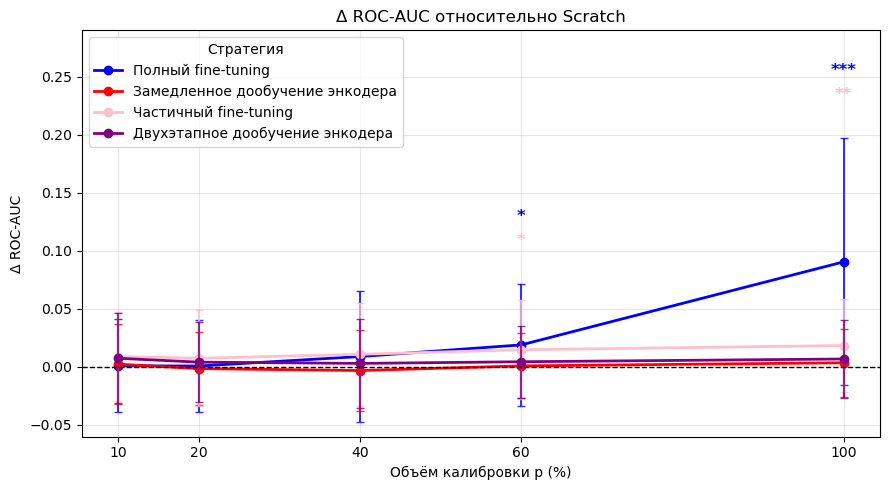

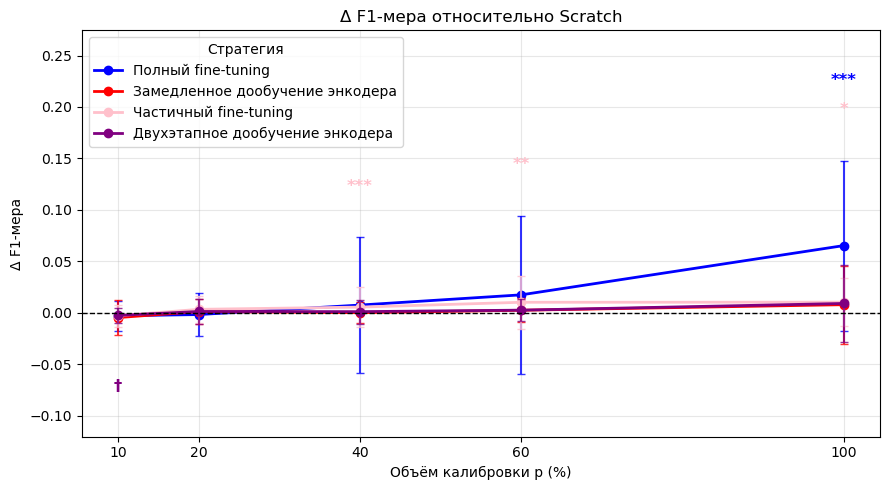

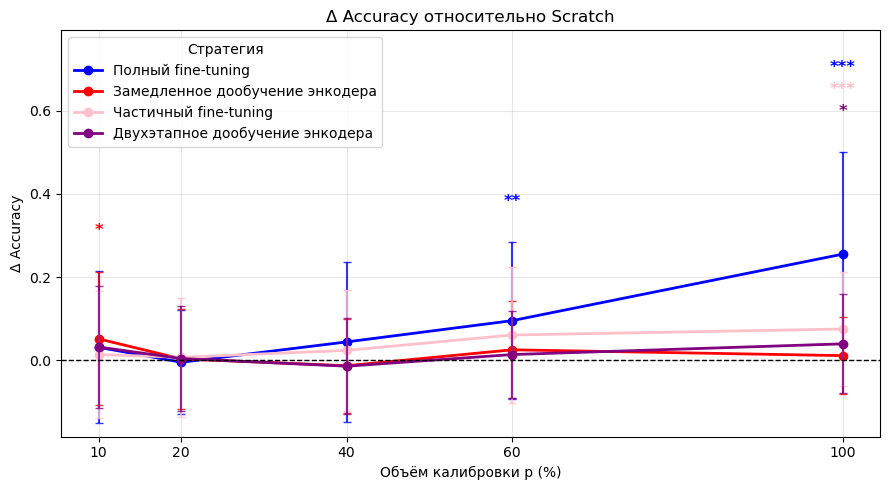

In [14]:
fig = plot_delta_metric("delta_auc", "Δ ROC-AUC", stats_df)
fig = plot_delta_metric("delta_f1", "Δ F1-мера", stats_df)
fig = plot_delta_metric("delta_accuracy", "Δ Accuracy", stats_df)

In [15]:
def save_plot_STAT(plot_func, metric, ylabel, stats_df, filename):
    fig = plot_func(metric, ylabel, stats_df)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [16]:
save_plot_STAT(plot_delta_metric, "delta_auc", "Δ ROC-AUC", stats_df, "delta_auc_vs_p_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_f1", "Δ F1-мера", stats_df, "delta_f1_vs_scratch_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_accuracy", "Δ Accuracy", stats_df, "delta_accuracy_vs_scratch_STAT.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_auc_vs_p_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_f1_vs_scratch_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\delta_accuracy_vs_scratch_STAT.png


## Одна общая таблица для разных объёмв калибровки

In [ ]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")


In [36]:
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

def run_wilcoxon2(values, alternative="two-sided"):
    values = pd.Series(values).dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

def build_reference(df_all, p_ref):
    return (
        df_all[
            (df_all["strategy"] == "scratch") &
            (df_all["p"] == p_ref)
        ][["subject_id", "auc", "f1", "accuracy"]]
        .rename(columns={
            "auc": f"auc_scratch{p_ref}",
            "f1": f"f1_scratch{p_ref}",
            "accuracy": f"accuracy_scratch{p_ref}"
        })
        .copy()
    )


def compare_with_reference(df_all, p_ref):
    metric_cols = ["auc", "f1", "accuracy"]

    df_ref = build_reference(df_all, p_ref)
    df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

    df_cmp = df_ssl.merge(df_ref, on="subject_id", how="inner")

    for m in metric_cols:
        df_cmp[f"delta_vs_scratch{p_ref}_{m}"] = (
            df_cmp[m] - df_cmp[f"{m}_scratch{p_ref}"]
        )

    return df_cmp


def build_stats_vs_scratch_refs(df_all, p_refs=[100, 60, 40, 20]):
    metric_cols = ["auc", "f1", "accuracy"]
    all_results = []

    for p_ref in p_refs:
        df_cmp = compare_with_reference(df_all, p_ref=p_ref)

        for (strategy, p), sub in df_cmp.groupby(["strategy", "p"]):
            for m in metric_cols:
                delta_col = f"delta_vs_scratch{p_ref}_{m}"
                vals = sub[delta_col].dropna()

                all_results.append({
                    "strategy": strategy,
                    "p": p,
                    "p_ref": p_ref,
                    "metric": m,
                    "n": len(vals),
                    "mean_diff": vals.mean(),
                    "std_diff": vals.std(),
                    "median_diff": vals.median(),
                    "frac_ge_0": (vals >= 0).mean(),
                    "p_value": run_wilcoxon2(vals),
                })

    stats_all_refs = pd.DataFrame(all_results)

    # Поправка BH отдельно внутри каждой метрики
    # Так аккуратнее, чем смешивать auc/f1/accuracy в одну поправку
    stats_all_refs["p_adj"] = np.nan

    for metric, idx in stats_all_refs.groupby("metric").groups.items():
        pvals = stats_all_refs.loc[idx, "p_value"].values
        stats_all_refs.loc[idx, "p_adj"] = multipletests(
            pvals,
            method="fdr_bh"
        )[1]

    stats_all_refs["significant"] = stats_all_refs["p_adj"] < 0.05

    return stats_all_refs

In [37]:
stats_all_refs = build_stats_vs_scratch_refs(
    df_all,
    p_refs=[100, 60, 40, 20]
)

display(stats_all_refs.head())

,strategy,p,p_ref,metric,n,mean_diff,std_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,full_ft,0,100,auc,61,-0.055547,0.098337,-0.029860,0.163934,5.581985e-09,6.773134e-08,True
1,full_ft,0,100,f1,61,-0.021992,0.049471,-0.005212,0.196721,1.751756e-06,2.102107e-05,True
2,full_ft,0,100,accuracy,61,0.106847,0.217448,0.073506,0.688525,4.577269e-05,3.661815e-04,True
3,full_ft,10,100,auc,61,-0.040586,0.050199,-0.033594,0.180328,1.201364e-08,9.253135e-08,True
4,full_ft,10,100,f1,61,-0.007955,0.026129,-0.000725,0.377049,5.226189e-03,1.194557e-02,True


In [38]:
def make_calibration_matrix(stats_all_refs, metric="auc"):
    strategies = [
        "full_ft",
        "low_lr_encoder",
        "partial_ft",
        "warmup",
    ]

    p_ssl_values = [10, 20, 40, 60]
    p_ref_values = [100, 60, 40, 20]

    df_stat = stats_all_refs[stats_all_refs["metric"] == metric].copy()

    def format_cell(row):
        return (
            f"Δ={row['mean_diff']:.3f}\n"
            f"med = {row['median_diff']:.3f}\n"
            f"p={row['p_adj']:.3g}\n"
            f"({row['frac_ge_0']:.2f})"
        )

    rows = []

    for strategy in strategies:
        for p_ssl in p_ssl_values:
            row_out = {
                "strategy": strategy,
                "p_ssl": f"p={p_ssl}%",
            }

            for p_ref in p_ref_values:
                col_name = f"scratch p={p_ref}%"

                # пустые клетки, где сравнение не имеет смысла
                if p_ssl >= p_ref:
                    row_out[col_name] = ""
                    continue

                sub = df_stat[
                    (df_stat["strategy"] == strategy)
                    & (df_stat["p"] == p_ssl)
                    & (df_stat["p_ref"] == p_ref)
                ]

                if sub.empty:
                    row_out[col_name] = ""
                else:
                    row_out[col_name] = format_cell(sub.iloc[0])

            rows.append(row_out)

    return pd.DataFrame(rows)

In [20]:
table_auc = make_calibration_matrix(stats_all_refs, metric="auc")
table_f1 = make_calibration_matrix(stats_all_refs, metric="f1")
table_acc = make_calibration_matrix(stats_all_refs, metric="accuracy")

display(table_auc)

,strategy,p_ssl,scratch p=100%,scratch p=60%,scratch p=40%,scratch p=20%
0,full_ft,p=10%,Δ=-0.041\nmed = -0.034\np=9.25e-08\n(0.18),Δ=-0.026\nmed = -0.025\np=1.3e-05\n(0.23),Δ=-0.020\nmed = -0.014\np=0.000452\n(0.33),Δ=-0.008\nmed = -0.006\np=0.106\n(0.43)
1,full_ft,p=20%,Δ=-0.032\nmed = -0.027\np=2.71e-07\n(0.20),Δ=-0.018\nmed = -0.014\np=0.000112\n(0.31),Δ=-0.012\nmed = -0.002\np=0.11\n(0.44),
2,full_ft,p=40%,Δ=-0.011\nmed = -0.007\np=0.0798\n(0.39),Δ=0.003\nmed = 0.004\np=0.986\n(0.51),,
3,full_ft,p=60%,Δ=0.004\nmed = -0.004\np=0.937\n(0.43),,,
4,low_lr_encoder,p=10%,Δ=-0.039\nmed = -0.035\np=6.77e-08\n(0.15),Δ=-0.025\nmed = -0.023\np=1.79e-06\n(0.21),Δ=-0.019\nmed = -0.019\np=5.16e-05\n(0.26),Δ=-0.006\nmed = -0.007\np=0.0771\n(0.41)
5,low_lr_encoder,p=20%,Δ=-0.034\nmed = -0.026\np=7.23e-08\n(0.16),Δ=-0.020\nmed = -0.015\np=9.52e-06\n(0.28),Δ=-0.014\nmed = -0.006\np=0.00604\n(0.34),
6,low_lr_encoder,p=40%,Δ=-0.023\nmed = -0.018\np=1.35e-05\n(0.23),Δ=-0.009\nmed = -0.004\np=0.0372\n(0.39),,
7,low_lr_encoder,p=60%,Δ=-0.014\nmed = -0.012\np=0.0026\n(0.33),,,
8,partial_ft,p=10%,Δ=-0.033\nmed = -0.025\np=9.75e-08\n(0.18),Δ=-0.018\nmed = -0.014\np=7.14e-05\n(0.31),Δ=-0.012\nmed = -0.008\np=0.00451\n(0.33),Δ=0.000\nmed = 0.001\np=0.973\n(0.51)
9,partial_ft,p=20%,Δ=-0.025\nmed = -0.019\np=1.02e-06\n(0.21),Δ=-0.011\nmed = -0.007\np=0.00587\n(0.33),Δ=-0.005\nmed = -0.001\np=0.335\n(0.48),


In [21]:
out_path = TAB_DIR / "calibration_reduction_tables.xlsx"

with pd.ExcelWriter(out_path) as writer:
    table_auc.to_excel(writer, sheet_name="ROC-AUC", index=False)
    table_f1.to_excel(writer, sheet_name="F1", index=False)
    table_acc.to_excel(writer, sheet_name="Accuracy", index=False)

out_path

WindowsPath('c:/Users/Таисия/Desktop/МФТИ/Диплом_BCI/diploma-bciP300-ssl/outputs/downstream/test_10epochs/tables/calibration_reduction_tables.xlsx')

In [45]:
metric = "auc"  # "auc" или "f1", "accuracy"

important_cells = stats_all_refs[
    (stats_all_refs["metric"] == metric) &
    ((stats_all_refs["mean_diff"] >= 0) |
    (stats_all_refs["median_diff"] >= 0))
].copy()

important_cells = important_cells[
    important_cells["p"] < important_cells["p_ref"]
]

important_cells = important_cells[important_cells["p"] > 0]

important_cells = important_cells[
    ["strategy", "p", "p_ref", "mean_diff", "median_diff", "p_adj", "frac_ge_0"]
].sort_values(["strategy", "p", "p_ref"])

for _, row in important_cells.iterrows():
    print(
        f"{row['strategy']} | p={row['p']} vs scratch p={row['p_ref']} → "
        f"Δ={row['mean_diff']:.3f}, med={row['median_diff']:.3f}, "
        f"p={row['p_adj']:.3g}, ({row['frac_ge_0']:.2f})"
    )

full_ft | p=40 vs scratch p=60 → Δ=0.003, med=0.004, p=0.986, (0.51)
full_ft | p=60 vs scratch p=100 → Δ=0.004, med=-0.004, p=0.937, (0.43)
partial_ft | p=10 vs scratch p=20 → Δ=0.000, med=0.001, p=0.973, (0.51)
partial_ft | p=40 vs scratch p=60 → Δ=0.005, med=0.001, p=0.358, (0.52)
partial_ft | p=60 vs scratch p=100 → Δ=0.000, med=-0.005, p=0.842, (0.43)


### Графики

In [39]:
def plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy,
    p_ref,
    metric="auc",
    p_values=(10, 20, 40, 60, 100),
    highlight_p=None,
    equal_band=0.01,
    save=False,
):
    fig, ax = plt.subplots(figsize=(8, 5))

    sub = stats_all_refs[
        (stats_all_refs["strategy"] == strategy)
        & (stats_all_refs["p_ref"] == p_ref)
        & (stats_all_refs["metric"] == metric)
        & (stats_all_refs["p"].isin(p_values))
    ].copy()

    sub = (
        sub
        .set_index("p")
        .reindex(p_values)
        .reset_index()
    )

    x = sub["p"]
    y = sub["mean_diff"]

    label = (
        f"'{STRATEGY_RU.get(strategy, strategy)}' "
        f"vs 'Обучение с нуля' (p={p_ref})"
    )

    ax.plot(
        x, y,
        marker="o",
        linewidth=2,
        color=COLORS[strategy],
        label=label,
    )

    # error bars если есть std
    if "std_diff" in sub.columns:
        yerr = sub["std_diff"]

        ax.errorbar(
            x, y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    # зона равенства
    ax.axhspan(
        -equal_band,
        equal_band,
        color="gray",
        alpha=0.15,
        label=f"≈ одинаковое качество (±{equal_band})",
    )

    # выделение точки
    if highlight_p is not None and highlight_p in sub["p"].values:
        row_h = sub[sub["p"] == highlight_p].iloc[0]

        ax.scatter(
            highlight_p,
            row_h["mean_diff"],
            color="red",
            s=80,
            zorder=5,
            label=f"p={highlight_p}: без потери качества",
        )

    metric_ru = {
        "auc": "ROC-AUC",
        "f1": "F1-мера",
        "accuracy": "Accuracy",
    }.get(metric, metric)

    ax.set_xticks(list(p_values))
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(f"Δ {metric_ru} относительно обучения с нуля (p={p_ref})")
    ax.set_title(
        f"{metric_ru}: {STRATEGY_RU.get(strategy, strategy)} vs Scratch (p={p_ref})"
    )

    ax.legend(title="Сравнение")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    # --- автосохранение ---
    if save:
        metric_name = metric.lower()
        strategy_name = strategy.lower()
        filename = f"{metric_name}_{strategy_name}_vs_scratch{p_ref}.png"

        save_path = FIG_DIR / filename

        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Сохранено: {save_path}")
    else:
        plt.show()

    return fig

#### Рисуем

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_10epochs\figures\auc_partial_ft_vs_scratch100.png


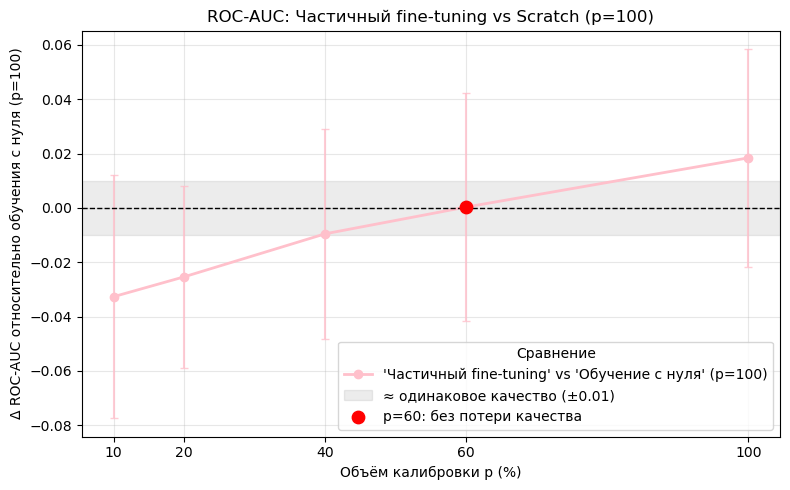

In [44]:
plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy="partial_ft",
    p_ref=100,
    metric="auc",
    highlight_p=60,
    save=True
)